In [1]:
import sys
import os
sys.path.append(os.path.abspath("../.."))
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from tinyconformal.regressor import ConformalizedRegressor, ExactnessBound
from tinyconformal.plot import plot_prediction_intervals
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import median_absolute_error
import numpy as np

In [2]:
data = fetch_california_housing(as_frame=True)
X, y = data.data, data.target

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_calib, y_train, y_calib = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

In [4]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1, oob_score=True, max_depth=int(np.ceil(np.log2(len(X_train)) - 1)))
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,13
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [ ]:
tilde_beta, beta = ExactnessBound.estimate_icp_bound(rf, X_train, y_train, p=0.95, cv=10)

In [ ]:
reg = ConformalizedRegressor(rf, alpha=0.05)
reg.unlabeled_fit(X_calib, tilde_beta=tilde_beta, beta=beta)

ValueError: The parameter 'beta' must be provided. Without 'beta', the actual lower coverage bound (1 - alpha - beta) cannot be determined. Consider using `tilde_beta, beta = ExactnessBound.estimate_icp_bound(...)`.

In [ ]:
y_pred_intervals = reg.predict_interval(X_test)
y_pred = reg.predict(X_test)

In [ ]:
reg.evaluate(X_test, y_test)

{'total': 4128,
 'alpha': 0.05,
 'coverage_rate': np.float64(0.951),
 'interval_width_mean': np.float64(2.197),
 'mwis': np.float64(3.212),
 'mae': np.float64(0.341),
 'mbe': np.float64(0.007),
 'mse': np.float64(0.269)}

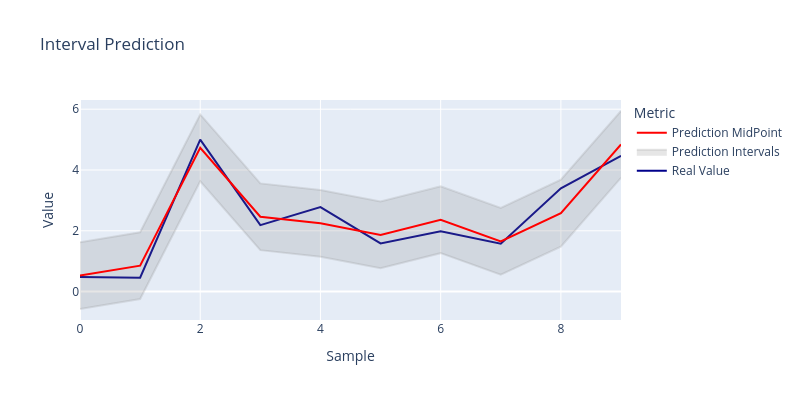

In [ ]:
plot_prediction_intervals(y_pred_intervals[:10], y_pred[:10], y_test[:10], fig_type="png")